## Setup & Device
PyTorch aur zaroori modules (`nn`, `optim`, `transforms`, `DataLoader`) import kiye. `torch.device()` se check kiya ki GPU (`cuda`) available hai ya nahi — agar hai to GPU use hoga, warna CPU pe training chalegi.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Normalization Values
CIFAR-100 dataset ke standard **mean** aur **std deviation** values define kiye (RGB ke teen channels ke liye). Ye values images ko normalize karne ke liye use hoti hain, jisse model training stable aur fast hoti hai.

In [6]:
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

## Data Transforms (Augmentation)
- **`train_transform`**: Training images pe data augmentation apply karta hai — random horizontal flip aur random rotation (±16°), taaki model generalize achha kare aur overfit na ho. Uske baad tensor mein convert karke normalize karta hai.
- **`val_transform`**: Validation images sirf tensor + normalize hoti hain, koi augmentation nahi — kyunki validation data ko as-is evaluate karna hota hai.

In [10]:
train_transform = transforms.Compose([
   transforms.RandomHorizontalFlip(),
   transforms.RandomRotation(16),
   transforms.ToTensor(),
   transforms.Normalize(cifar100_mean, cifar100_std)
])

val_transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize(cifar100_mean, cifar100_std)
])

## Prototype Classes (Subset)
CIFAR-100 ke 100 classes mein se sirf **9 classes** choose ki hain (flowers, animals, insects ka chhota mix) — taaki pehle ek chhote dataset pe prototype model test kiya ja sake, poore dataset pe jaane se pehle.

In [11]:
subset_target_classes = [
    'orchid', 'poppy', 'sunflower',
    'fox', 'raccoon', 'skunk',
    'butterfly', 'caterpillar', 'cockroach'
]

## Dataset Load Karna
`helper_utils.load_cifar100_subset()` function se CIFAR-100 dataset load kiya aur sirf upar chuni gayi 9 classes filter kar ke `train_dataset_proto` aur `val_dataset_proto` banaye.

In [22]:
train_dataset_proto, val_dataset_proto = helper_utils.load_cifar100_subset(subset_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 9 classes...
Filtering complete. Returning training and validation datasets.


## DataLoaders Banana
`DataLoader` se dataset ko batches (size 64) mein todte hain. `train_loader_proto` mein `shuffle=True` hai taaki har epoch mein data ka order random rahe; `val_loader_proto` mein `shuffle=False` hai kyunki validation mein order matter nahi karta.

In [23]:
batch_size = 64

train_loader_proto = DataLoader(train_dataset_proto, batch_size=batch_size, shuffle=True)

val_loader_proto = DataLoader(val_dataset_proto, batch_size=batch_size, shuffle=False)

## Sample Images Visualize Karna
`helper_utils.visualise_images()` se dataset ke kuch random images ek 3x3 grid mein dikhaye — taaki visually confirm ho sake ki data aur labels sahi load hue hain.

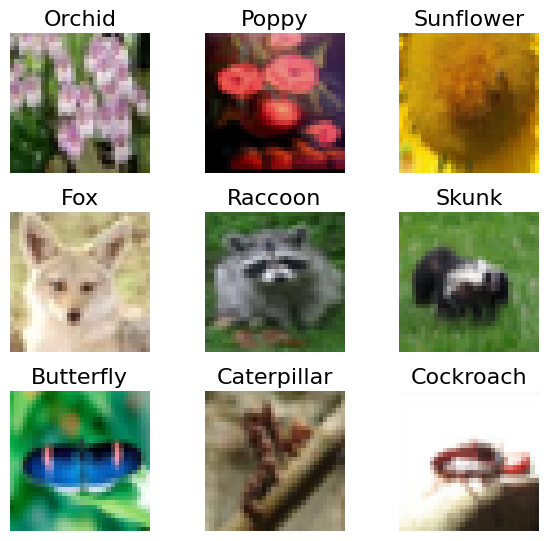

In [24]:
helper_utils.visualise_images(train_dataset_proto, grid=(3, 3))

## CNN Model Architecture (SimpleCNN)
Ek Convolutional Neural Network define kiya jisme:
- **3 Convolutional Blocks**: Har block mein `Conv2d` (features extract karta hai) → `ReLU` (non-linearity) → `MaxPool2d` (image size aadhi karta hai). Channels 3 → 32 → 64 → 128 badhte jaate hain.
- **Flatten Layer**: 2D feature maps ko 1D vector mein convert karta hai.
- **2 Fully Connected Layers**: `fc1` (features ko 512 units mein map karta hai) aur `fc2` (final classification, `num_classes` output deta hai). Beech mein `Dropout(0.5)` hai jo overfitting rokta hai training ke dauran randomly kuch neurons off kar ke.

In [25]:
class SimpleCNN(nn.Module):
    """
    A simple Convolutional Neural Network model.

    The architecture consists of three convolutional blocks followed by two
    fully connected layers for classification.
    """
    def __init__(self, num_classes):
        """
        Initializes the layers of the neural network.

        Args:
            num_classes: The number of output classes for the final layer.
        """
        # Call the constructor of the parent class (nn.Module)
        super(SimpleCNN, self).__init__()
        
        # Define the first convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define the second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define the third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define the layer to flatten the feature maps
        self.flatten = nn.Flatten()

        # Define the fully connected (dense) layers
        # Input image is 32x32, after 3 pooling layers: 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)


    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x: The input tensor of shape (batch_size, channels, height, width).

        Returns:
            The output tensor containing the logits for each class.
        """
        # Pass input through the first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Pass feature maps through the second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Pass feature maps through the third convolutional block
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Flatten the output for the fully connected layers
        x = self.flatten(x)

        # Pass the flattened features through the fully connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        # Return the final output logits
        return x

## Prototype Model Banana
9-class dataset ke hisaab se ek prototype model instance banaya — `num_classes` dataset se automatically le liya.

In [26]:
num_classes = len(train_dataset_proto.classes)
prototype_model = SimpleCNN(num_classes)

## Data Flow Debugging Function
`print_data_flow()` function ek dummy input tensor (`1, 3, 32, 32` shape — batch=1, channels=3, height=32, width=32) model ke har layer se pass karta hai aur har step ke baad tensor ka shape print karta hai. Ye samajhne/debug karne ke liye useful hai ki data model ke andar kaise transform ho raha hai.

In [28]:
def print_data_flow(model):
    """
    Prints the shape of a tensor as it flows through each layer of the model.

    Args:
        model: An instance of the PyTorch model to inspect.
    """
    # Create a sample input tensor (batch_size, channels, height, width)
    x = torch.randn(1, 3, 32, 32)

    # Track the tensor shape at each stage
    print(f"Input shape: \t\t{x.shape}")

    # First conv block
    x = model.conv1(x)
    print(f"After conv1: \t\t{x.shape}")
    x = model.relu1(x)
    x = model.pool1(x)
    print(f"After pool1: \t\t{x.shape}")

    # Second conv block
    x = model.conv2(x)
    print(f"After conv2: \t\t{x.shape}")
    x = model.relu2(x)
    x = model.pool2(x)
    print(f"After pool2: \t\t{x.shape}")

    # Third conv block
    x = model.conv3(x)
    print(f"After conv3: \t\t{x.shape}")
    x = model.relu3(x)
    x = model.pool3(x)
    print(f"After pool3: \t\t{x.shape}")

    # Flatten using the model's flatten layer
    x = model.flatten(x)
    print(f"After flatten: \t\t{x.shape}")

    # Fully connected layers
    x = model.fc1(x)
    print(f"After fc1: \t\t{x.shape}")
    x = model.relu4(x)
    x = model.dropout(x)
    x = model.fc2(x)
    print(f"Output shape (fc2): \t{x.shape}")

## Model Structure aur Data Flow Check
Prototype model ka pura structure print kiya, aur `print_data_flow()` call kar ke dekha ki input se output tak tensor shape kaise change hoti hai layer-by-layer.

In [29]:
print(prototype_model)

print("\n--- Tracing Data Flow ---")
print_data_flow(prototype_model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)

--- Tracing Data Flow ---
Input shape: 		torch.Size([1, 3, 32, 32])
After conv1: 		torch.Size([1, 32, 32, 32])
After pool1: 		torch.Size([1, 32, 16, 16])
After conv2: 		torch.Size([1, 64, 16, 16])
After pool2: 		t

## Loss Function & Optimizer
- **`CrossEntropyLoss`**: Multi-class classification ke liye standard loss function, prediction aur actual label ke beech ka difference measure karta hai.
- **`Adam` Optimizer**: Model ke weights ko gradients ke basis pe update karta hai, learning rate `0.001` ke saath.

In [31]:
loss_function = nn.CrossEntropyLoss()

optimizer_prototype = optim.Adam(prototype_model.parameters(), lr=0.001)

## Training Loop Function
`training_loop()` ek reusable function hai jo har epoch mein do phases follow karta hai:
1. **Training phase** (`model.train()`): Har batch pe forward pass → loss calculate → backward pass (gradients) → `optimizer.step()` se weights update.
2. **Validation phase** (`model.eval()`, `torch.no_grad()`): Bina gradient tracking ke model ko evaluate karta hai, validation loss aur accuracy calculate karta hai.

Har epoch ke end mein train loss, validation loss, aur validation accuracy print hoti hai. Function training ke end mein trained model aur saari metrics return karta hai.

In [32]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    """
    Trains and validates a PyTorch neural network model.

    Args:
        model: The neural network model to be trained.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        loss_function: The loss function to use for training.
        optimizer: The optimization algorithm.
        num_epochs: The total number of epochs to train for.
        device: The device (e.g., 'cpu' or 'cuda') to run the training on.

    Returns:
        A tuple containing:
        - The trained model.
        - A list of metrics [train_losses, val_losses, val_accuracies].
    """
    # Move the model to the specified device (CPU or GPU)
    model.to(device)
    
    # Initialize lists to store training and validation metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Print a message indicating the start of the training process
    print("--- Training Started ---")
    
    # Loop over the specified number of epochs
    for epoch in range(num_epochs):
        # Set the model to training mode
        model.train()
        # Initialize running loss for the current epoch
        running_loss = 0.0
        # Iterate over batches of data in the training loader
        for images, labels in train_loader:
            # Move images and labels to the specified device
            images, labels = images.to(device), labels.to(device)
            
            # Clear the gradients of all optimized variables
            optimizer.zero_grad()
            # Perform a forward pass to get model outputs
            outputs = model(images)
            # Calculate the loss
            loss = loss_function(outputs, labels)
            # Perform a backward pass to compute gradients
            loss.backward()
            # Update the model parameters
            optimizer.step()
            
            # Accumulate the training loss for the batch
            running_loss += loss.item() * images.size(0)
            
        # Calculate the average training loss for the epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        # Append the epoch loss to the list of training losses
        train_losses.append(epoch_loss)
        
        # Set the model to evaluation mode
        model.eval()
        # Initialize running validation loss and correct predictions count
        running_val_loss = 0.0
        correct = 0
        total = 0
        # Disable gradient calculations for validation
        with torch.no_grad():
            # Iterate over batches of data in the validation loader
            for images, labels in val_loader:
                # Move images and labels to the specified device
                images, labels = images.to(device), labels.to(device)
                
                # Perform a forward pass to get model outputs
                outputs = model(images)
                
                # Calculate the validation loss for the batch
                val_loss = loss_function(outputs, labels)
                # Accumulate the validation loss
                running_val_loss += val_loss.item() * images.size(0)
                
                # Get the predicted class labels
                _, predicted = torch.max(outputs, 1)
                # Update the total number of samples
                total += labels.size(0)
                # Update the number of correct predictions
                correct += (predicted == labels).sum().item()
                
        # Calculate the average validation loss for the epoch
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        # Append the epoch validation loss to the list
        val_losses.append(epoch_val_loss)
        
        # Calculate the validation accuracy for the epoch
        epoch_accuracy = 100.0 * correct / total
        # Append the epoch accuracy to the list
        val_accuracies.append(epoch_accuracy)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")
        
    # Print a message indicating the end of the training process
    print("--- Finished Training ---")
    
    # Consolidate all metrics into a single list
    metrics = [train_losses, val_losses, val_accuracies]
    
    # Return the trained model and the collected metrics
    return model, metrics

## Prototype Model Training (9 Classes)
Prototype model ko 9-class chhote dataset pe **15 epochs** ke liye train kiya. Training ke baad `plot_training_metrics()` se loss aur accuracy ka graph plot kiya, taaki dekh sake model kaise perform kar raha hai training ke dauran.

--- Training Started ---
Epoch [1/15], Train Loss: 0.4556, Val Loss: 0.7362, Val Accuracy: 77.22%
Epoch [2/15], Train Loss: 0.4134, Val Loss: 0.7053, Val Accuracy: 79.44%
Epoch [3/15], Train Loss: 0.3648, Val Loss: 0.7488, Val Accuracy: 77.67%
Epoch [4/15], Train Loss: 0.3578, Val Loss: 0.6872, Val Accuracy: 78.78%
Epoch [5/15], Train Loss: 0.3161, Val Loss: 0.8073, Val Accuracy: 77.11%
Epoch [6/15], Train Loss: 0.3228, Val Loss: 0.6954, Val Accuracy: 79.89%
Epoch [7/15], Train Loss: 0.3028, Val Loss: 0.7303, Val Accuracy: 80.00%
Epoch [8/15], Train Loss: 0.2723, Val Loss: 0.7479, Val Accuracy: 79.89%
Epoch [9/15], Train Loss: 0.2486, Val Loss: 0.7120, Val Accuracy: 79.89%
Epoch [10/15], Train Loss: 0.2469, Val Loss: 0.7252, Val Accuracy: 81.44%
Epoch [11/15], Train Loss: 0.2348, Val Loss: 0.8108, Val Accuracy: 78.78%
Epoch [12/15], Train Loss: 0.2358, Val Loss: 0.7907, Val Accuracy: 79.67%
Epoch [13/15], Train Loss: 0.2235, Val Loss: 0.7809, Val Accuracy: 80.67%
Epoch [14/15], Train L

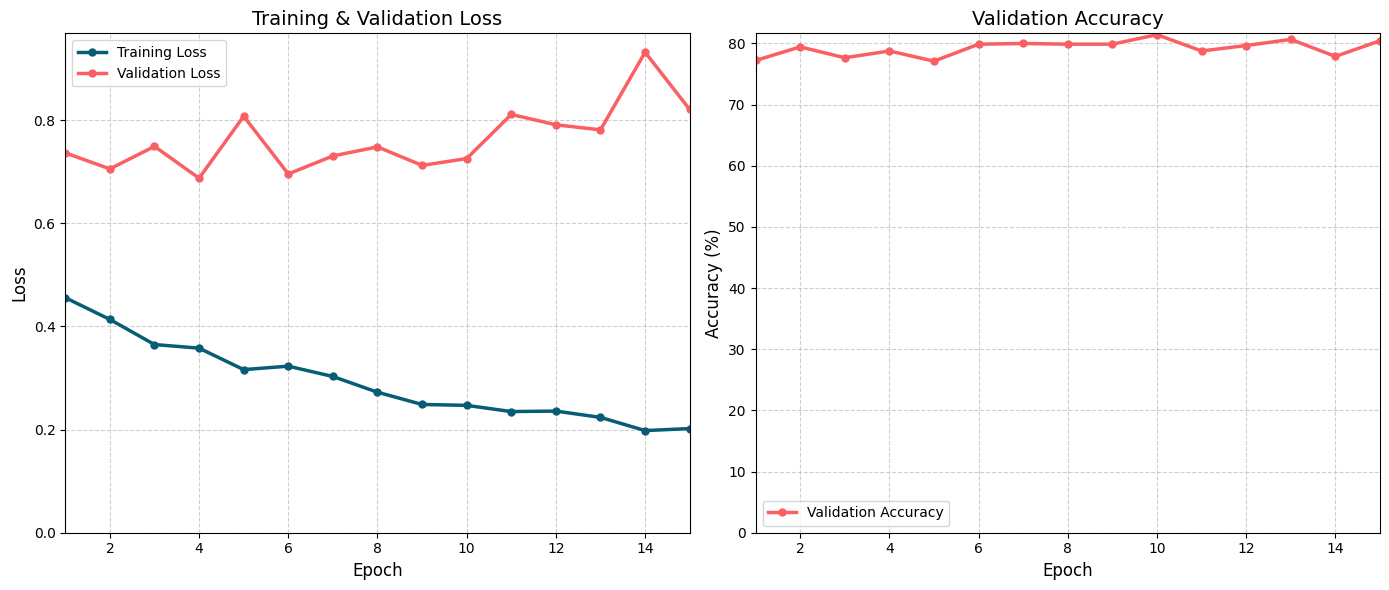

In [39]:
trained_proto_model, training_metrics_proto = training_loop(
    model=prototype_model, 
    train_loader=train_loader_proto, 
    val_loader=val_loader_proto, 
    loss_function=loss_function, 
    optimizer=optimizer_prototype, 
    num_epochs=15, 
    device=device
)

print("\n--- Training Plots ---\n")
helper_utils.plot_training_metrics(training_metrics_proto)

## Predictions Visualize Karna
Trained prototype model se validation set ke kuch images pe predictions nikaal ke ek 3x3 grid mein dikhaye — taaki visually verify ho sake ki model sahi predict kar raha hai ya nahi.

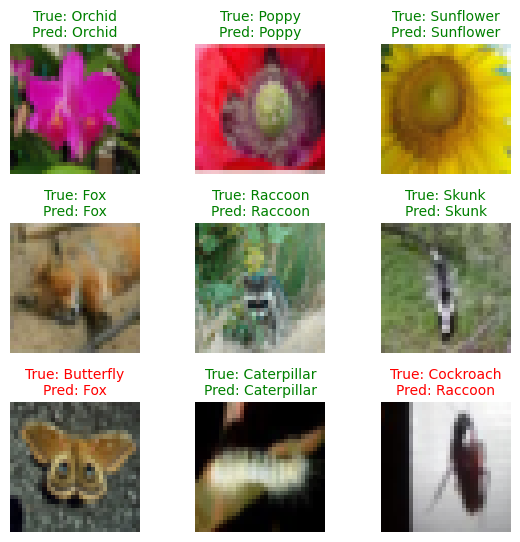

In [34]:
helper_utils.visualise_predictions(
    model=trained_proto_model, 
    data_loader=val_loader_proto, 
    device=device, 
    grid=(3, 3)
)

## Full Dataset Load Karna (15 Classes)
Ab prototype (9 classes) se aage badhte hue, **pura 15-class dataset** load kiya (flowers: orchid, poppy, rose, sunflower, tulip; animals: fox, porcupine, possum, raccoon, skunk; insects: bee, beetle, butterfly, caterpillar, cockroach).

In [35]:
all_target_classes = [
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

train_dataset, val_dataset = helper_utils.load_cifar100_subset(all_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


## Full Dataset ke DataLoaders
15-class dataset ke liye naye `train_loader` aur `val_loader` banaye, same batch size (64) ke saath.

In [38]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Sample Images (Note: chhota bug)
Yahan `train_dataset_proto` (purana 9-class dataset) ke images dikhaye ja rahe hain, jabki naya `train_dataset` (15-class) dikhana intended tha — ye copy-paste ka chhota bug lagta hai.

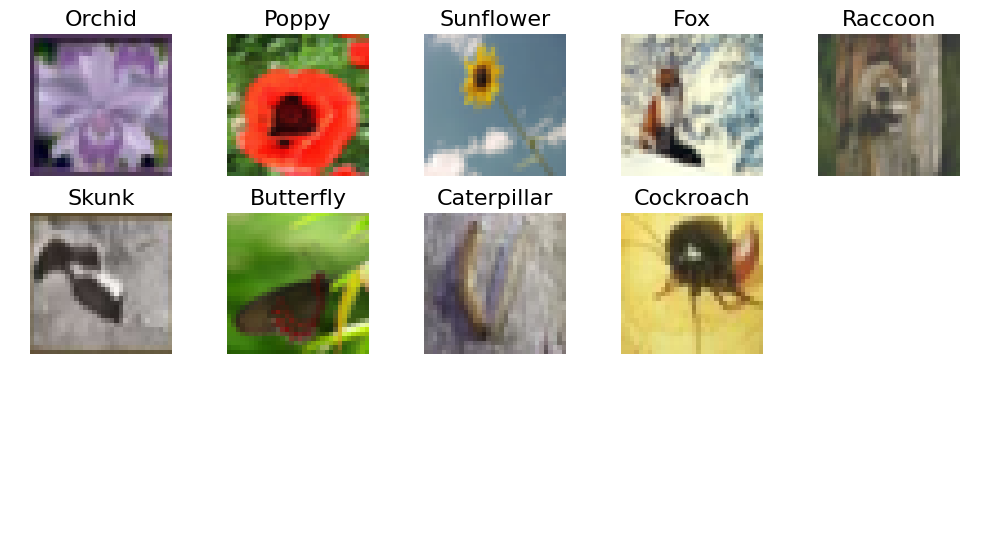

In [40]:
helper_utils.visualise_images(train_dataset_proto, grid=(3, 5))

## Final Model Banana (15 Classes)
Same `SimpleCNN` architecture use karke ek naya model banaya jo ab **15 classes** predict karega (`num_classes = 15`).

In [41]:
num_classes = len(train_dataset.classes)

model = SimpleCNN(num_classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


## Final Model ka Optimizer
Naye 15-class model ke liye ek naya `Adam` optimizer banaya, same learning rate (`0.001`) ke saath.

In [42]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Final Model Training (25 Epochs)
Final model ko pure 15-class dataset pe **25 epochs** ke liye train kiya — ye notebook ka final/main deliverable model hai. Training ke baad loss aur accuracy ka graph plot kiya gaya.

In [ ]:
trained_model, training_metrics = training_loop(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=25, 
    device=device
)

print("\n--- Training Plots ---\n")
helper_utils.plot_training_metrics(training_metrics)

--- Training Started ---
